Prepare data

In [ ]:
%run data_preparation.py

/home/pawluk/nova/ml/assignment-1/NOVA_ML_Project1/data_preparation.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  _df = _df.groupby("traj_id", group_keys=False).apply(mark)


# Task 4: Nonparametric Model — the k-Nearest Neighbors Regressor

## Task 4.1 Development

Develop a function to validate a kNN regression model with the following signature:

**TODO**

> How does your training/inference times vary with $k$? Report on the slides showing evidence of the behavior you are studying.

Find the best error

In [10]:
import time

def validate_knn_regression(X_train, y_train, X_val, y_val, k=range(1, 15)):
    rmse_list = []
    train_times = []
    inference_times = []
    
    print(f"{'k':<5} {'RMSE':<12} {'Train Time (s)':<15} {'Inference Time (s)':<20}")
    print("-" * 70)
    
    for n_neighbors in k:
        model = make_pipeline(
            StandardScaler(),
            KNeighborsRegressor(n_neighbors=n_neighbors)
        )
        
        # Measure training time
        start_train = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start_train
        train_times.append(train_time)
        
        # Measure inference time
        start_inference = time.time()
        y_pred = model.predict(X_val)
        inference_time = time.time() - start_inference
        inference_times.append(inference_time)
        
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        rmse_list.append(rmse)
        
        print(f"{n_neighbors:<5} {rmse:<12.5f} {train_time:<15.6f} {inference_time:<20.6f}")
    
    # Create figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Plot 1: RMSE vs k
    axes[0].plot(k, rmse_list, marker='o', linewidth=2, markersize=6, color='blue')
    axes[0].set_title("RMSE vs Number of Neighbors (k)", fontsize=12)
    axes[0].set_xlabel("Number of Neighbors (k)")
    axes[0].set_ylabel("Validation RMSE")
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xticks(k)
    best_k_idx = np.argmin(rmse_list)
    axes[0].axvline(k[best_k_idx], color='r', linestyle='--', alpha=0.5, 
                    label=f'Best k={k[best_k_idx]}')
    axes[0].legend()
    
    # Plot 2: Training time vs k
    axes[1].plot(k, train_times, marker='s', linewidth=2, markersize=6, color='green')
    axes[1].set_title("Training Time vs k", fontsize=12)
    axes[1].set_xlabel("Number of Neighbors (k)")
    axes[1].set_ylabel("Training Time (seconds)")
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xticks(k)
    
    # Plot 3: Inference time vs k
    axes[2].plot(k, inference_times, marker='^', linewidth=2, markersize=6, color='orange')
    axes[2].set_title("Inference Time vs k", fontsize=12)
    axes[2].set_xlabel("Number of Neighbors (k)")
    axes[2].set_ylabel("Inference Time (seconds)")
    axes[2].grid(True, alpha=0.3)
    axes[2].set_xticks(k)
    
    plt.tight_layout()
    plt.show()
    
    best_k = k[best_k_idx]
    best_rmse = min(rmse_list)
    
    print("\n" + "="*70)
    print(f"Best k: {best_k} with RMSE: {best_rmse:.5f}")
    print(f"Training time at best k: {train_times[best_k_idx]:.6f}s")
    print(f"Inference time at best k: {inference_times[best_k_idx]:.6f}s")
    print("="*70)
    
    # Summary statistics
    print(f"\nTime Statistics:")
    print(f"  Average training time: {np.mean(train_times):.6f}s (±{np.std(train_times):.6f}s)")
    print(f"  Average inference time: {np.mean(inference_times):.6f}s (±{np.std(inference_times):.6f}s)")
    
    return {
        'k_values': list(k),
        'rmse_list': rmse_list,
        'train_times': train_times,
        'inference_times': inference_times,
        'best_k': best_k,
        'best_rmse': best_rmse
    }


k     RMSE         Train Time (s)  Inference Time (s)  
----------------------------------------------------------------------
1     1.69228      0.048682        0.084930            
2     1.69178      0.026117        0.068097            
3     1.69195      0.026121        0.072745            
4     1.69159      0.029986        0.090255            
5     1.69153      0.028036        0.079701            
6     1.69123      0.026769        0.087784            
7     1.69096      0.024444        0.076796            
8     1.68441      0.024336        0.082297            
9     1.68019      0.028314        0.081257            
10    1.67605      0.025584        0.091651            
11    1.67634      0.026915        0.085060            
12    1.67607      0.025850        0.093888            
13    1.67230      0.029294        0.088573            
14    1.66880      0.025133        0.090973            


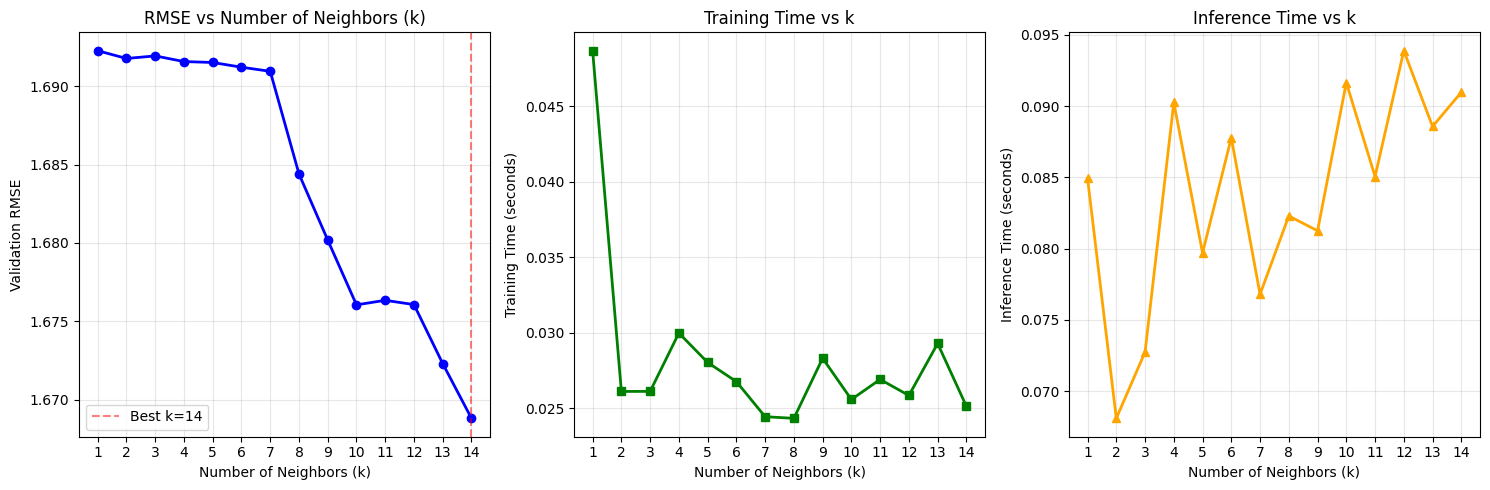


Best k: 14 with RMSE: 1.66880
Training time at best k: 0.025133s
Inference time at best k: 0.090973s

Time Statistics:
  Average training time: 0.028256s (±0.005898s)
  Average inference time: 0.083858s (±0.007277s)


{'k_values': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 'rmse_list': [np.float64(1.6922789283904347),
  np.float64(1.6917829315625397),
  np.float64(1.691947557915329),
  np.float64(1.6915861597012365),
  np.float64(1.6915271180015519),
  np.float64(1.6912264367624632),
  np.float64(1.6909629399959971),
  np.float64(1.6844097825075814),
  np.float64(1.6801890426653918),
  np.float64(1.676050103193691),
  np.float64(1.6763400687127097),
  np.float64(1.6760657278461437),
  np.float64(1.6722970176727545),
  np.float64(1.6688020350591901)],
 'train_times': [0.048682451248168945,
  0.026117324829101562,
  0.026121139526367188,
  0.029985904693603516,
  0.02803635597229004,
  0.026769399642944336,
  0.024444103240966797,
  0.024335861206054688,
  0.02831435203552246,
  0.02558422088623047,
  0.026915311813354492,
  0.025849580764770508,
  0.029294490814208984,
  0.02513289451599121],
 'inference_times': [0.0849301815032959,
  0.06809687614440918,
  0.07274532318115234,
  0.09025549888

In [11]:
validate_knn_regression(X_train, y_train, X_val, y_val, k=range(1, 15))

Run comprehensive comparison

In [12]:
def compare_feature_sets_knn(X_train, X_val, y_train, y_val, feature_names, k_range=range(1, 15)):
    # Convert to DataFrames
    X_train_df = pd.DataFrame(X_train, columns=feature_names)
    X_val_df = pd.DataFrame(X_val, columns=feature_names)
    
    results = {}
    
    # --- 1. Baseline (original features) ---
    print("\n" + "="*60)
    print("1. BASELINE - Original Features")
    print("="*60)
    results['baseline'] = validate_knn_regression(X_train, y_train, X_val, y_val, k_range)
    
    # --- 2. Reduced (remove correlated features) ---
    print("\n" + "="*60)
    print("2. REDUCED - Removed Correlated Features")
    print("="*60)
    
    # Find and remove highly correlated features
    corr = X_train_df.corr().abs().unstack().sort_values(ascending=False)
    corr = corr[corr < 0.9999]  # Ignore self-correlations
    top_corr = corr.head(5)
    features_to_remove = list({f1 for (f1, f2) in top_corr.index})
    
    print(f"Removing features: {features_to_remove}\n")
    
    X_train_reduced = X_train_df.drop(columns=features_to_remove).values
    X_val_reduced = X_val_df.drop(columns=features_to_remove).values
    
    results['reduced'] = validate_knn_regression(X_train_reduced, y_train, X_val_reduced, y_val, k_range)
    
    # --- 3. Augmented with distances ---
    print("\n" + "="*60)
    print("3. AUGMENTED - Added Pairwise Distances")
    print("="*60)
    
    def add_distances(df):
        df = df.copy()
        df["r12"] = np.sqrt((df["x_1"] - df["x_2"])**2 + (df["y_1"] - df["y_2"])**2)
        df["r13"] = np.sqrt((df["x_1"] - df["x_3"])**2 + (df["y_1"] - df["y_3"])**2)
        df["r23"] = np.sqrt((df["x_2"] - df["x_3"])**2 + (df["y_2"] - df["y_3"])**2)
        return df
    
    X_train_aug = add_distances(X_train_df).values
    X_val_aug = add_distances(X_val_df).values
    
    print(f"Added features: r12, r13, r23 (pairwise distances)\n")
    
    results['augmented'] = validate_knn_regression(X_train_aug, y_train, X_val_aug, y_val, k_range)
    
    # --- Summary comparison ---
    print("\n" + "="*60)
    print("SUMMARY: Best k and RMSE for each feature set")
    print("="*60)
    
    summary_df = pd.DataFrame({
        'Feature Set': ['Baseline', 'Reduced', 'Augmented (distances)'],
        'Best k': [results['baseline']['best_k'], 
                   results['reduced']['best_k'], 
                   results['augmented']['best_k']],
        'Best RMSE': [results['baseline']['best_rmse'], 
                      results['reduced']['best_rmse'], 
                      results['augmented']['best_rmse']],
        'Num Features': [X_train.shape[1], 
                         X_train_reduced.shape[1], 
                         X_train_aug.shape[1]]
    })
    
    summary_df['Δ RMSE vs Baseline'] = summary_df['Best RMSE'] - summary_df['Best RMSE'].iloc[0]
    
    print(summary_df.to_string(index=False))
    
    # Plot comparison of RMSE across all feature sets
    plt.figure(figsize=(10, 6))
    for name, color in [('baseline', 'blue'), ('reduced', 'green'), ('augmented', 'red')]:
        plt.plot(results[name]['k_values'], 
                results[name]['rmse_list'], 
                marker='o', 
                label=name.capitalize(), 
                linewidth=2,
                color=color,
                alpha=0.7)
    
    plt.title("k-NN Performance: Feature Set Comparison", fontsize=14)
    plt.xlabel("Number of Neighbors (k)", fontsize=12)
    plt.ylabel("Validation RMSE", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xticks(results['baseline']['k_values'])
    plt.tight_layout()
    plt.show()
    
    return results, summary_df


In [13]:
# Alternative without init_ prefix
feature_names = ['x_1', 'y_1', 'x_2', 'y_2', 'x_3', 'y_3', 't']


1. BASELINE - Original Features
k     RMSE         Train Time (s)  Inference Time (s)  
----------------------------------------------------------------------
1     1.69228      0.052296        0.112334            
2     1.69178      0.047016        0.093365            
3     1.69195      0.030240        0.094118            
4     1.69159      0.029133        0.079735            
5     1.69153      0.030605        0.075823            
6     1.69123      0.026912        0.076834            
7     1.69096      0.026382        0.079805            
8     1.68441      0.031181        0.098006            
9     1.68019      0.028488        0.087229            
10    1.67605      0.029560        0.091346            
11    1.67634      0.025689        0.089330            
12    1.67607      0.025059        0.095904            
13    1.67230      0.024770        0.093927            
14    1.66880      0.031588        0.099387            


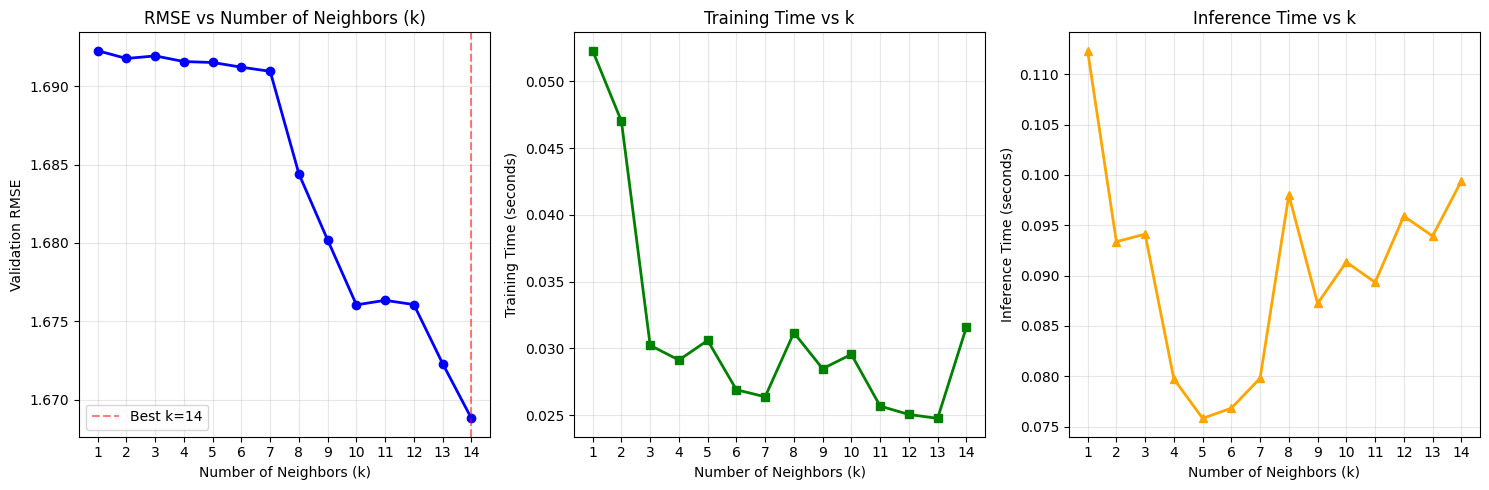


Best k: 14 with RMSE: 1.66880
Training time at best k: 0.031588s
Inference time at best k: 0.099387s

Time Statistics:
  Average training time: 0.031351s (±0.007845s)
  Average inference time: 0.090510s (±0.009708s)

2. REDUCED - Removed Correlated Features
Removing features: ['y_3', 'x_2', 'y_2', 'x_3']

k     RMSE         Train Time (s)  Inference Time (s)  
----------------------------------------------------------------------
1     2.05397      0.017150        0.021445            
2     1.70229      0.014931        0.020719            
3     1.59238      0.012828        0.023535            
4     1.54799      0.012283        0.023302            
5     1.53156      0.015122        0.023607            
6     1.51845      0.015955        0.029536            
7     1.51883      0.013989        0.025417            
8     1.53666      0.013241        0.029374            
9     1.53485      0.014598        0.028551            
10    1.52528      0.014647        0.032544            
11   

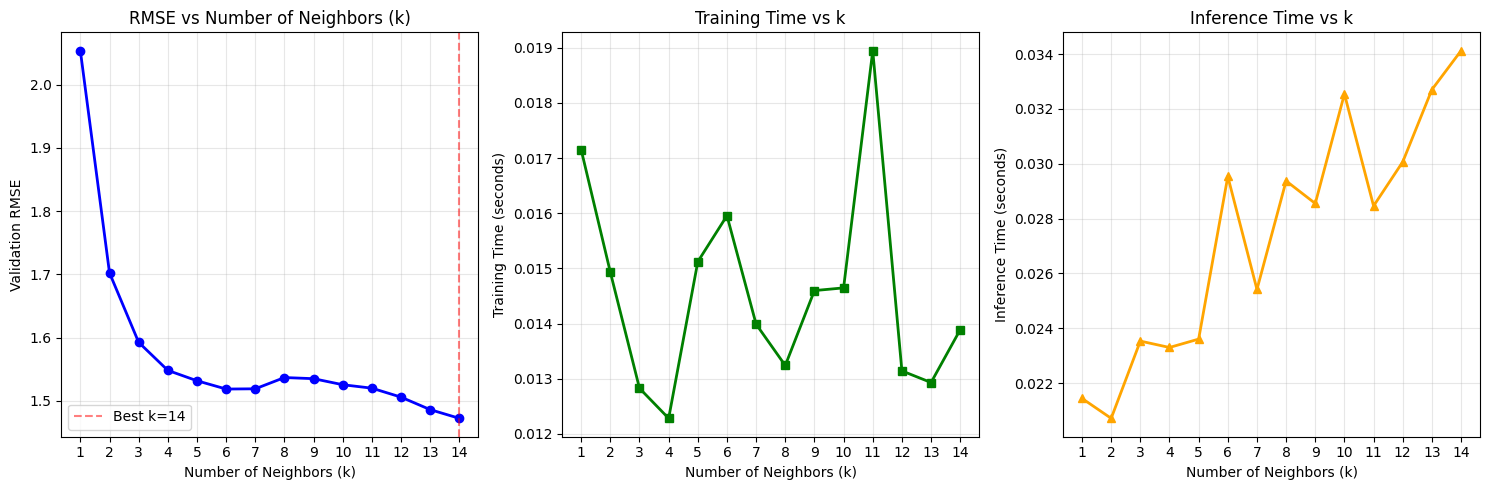


Best k: 14 with RMSE: 1.47207
Training time at best k: 0.013889s
Inference time at best k: 0.034120s

Time Statistics:
  Average training time: 0.014547s (±0.001767s)
  Average inference time: 0.027384s (±0.004208s)

3. AUGMENTED - Added Pairwise Distances
Added features: r12, r13, r23 (pairwise distances)

k     RMSE         Train Time (s)  Inference Time (s)  
----------------------------------------------------------------------
1     1.69199      0.038007        0.091998            
2     1.69107      0.033786        0.099577            
3     1.69156      0.036001        0.103418            
4     1.69106      0.037641        0.099009            
5     1.69109      0.033220        0.098440            
6     1.69071      0.036210        0.113586            
7     1.69061      0.035727        0.108857            
8     1.68927      0.038624        0.116707            
9     1.69003      0.039963        0.112083            
10    1.68919      0.036458        0.144248            
11 

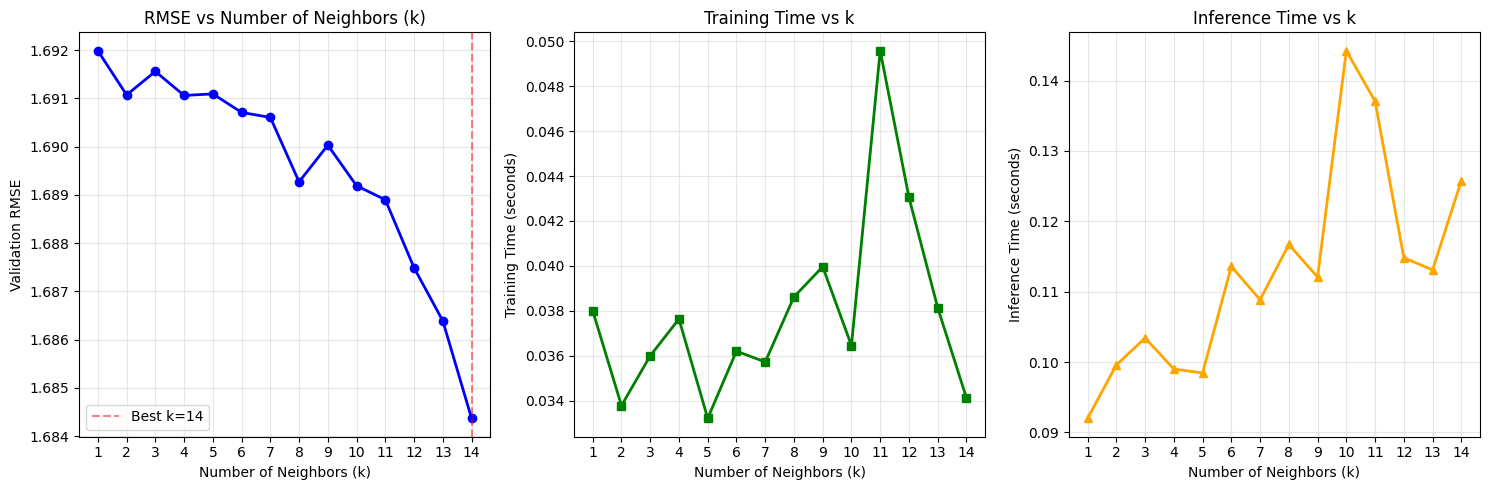


Best k: 14 with RMSE: 1.68437
Training time at best k: 0.034130s
Inference time at best k: 0.125771s

Time Statistics:
  Average training time: 0.037895s (±0.004089s)
  Average inference time: 0.112764s (±0.014329s)

SUMMARY: Best k and RMSE for each feature set
          Feature Set  Best k  Best RMSE  Num Features  Δ RMSE vs Baseline
             Baseline      14   1.668802             7            0.000000
              Reduced      14   1.472072             3           -0.196730
Augmented (distances)      14   1.684371            10            0.015569


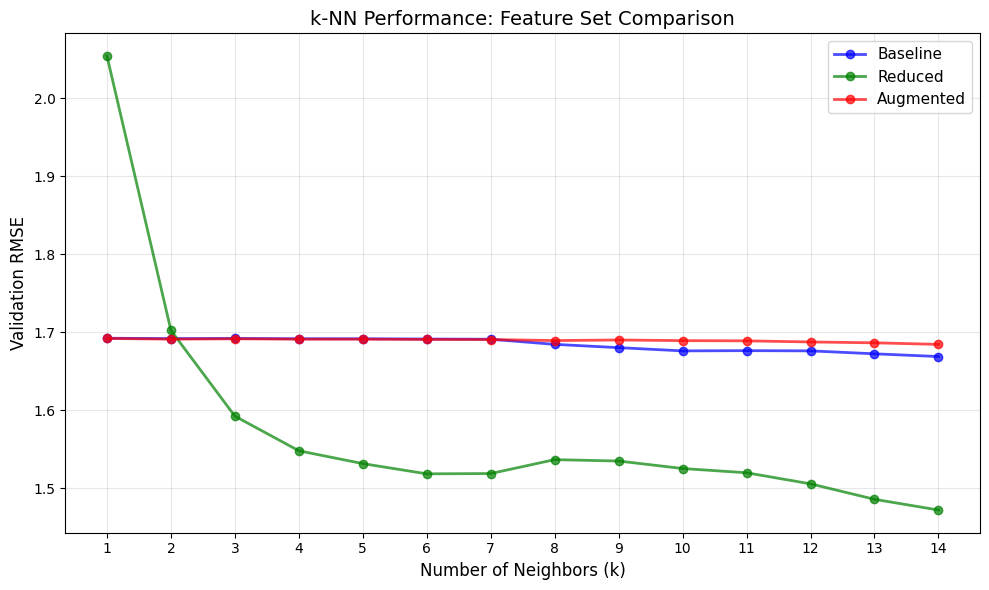

In [14]:
# Run comprehensive comparison

results, summary = compare_feature_sets_knn(
    X_train, X_val, y_train, y_val, 
    feature_names=feature_names,
    k_range=range(1, 15)
)

## Task 4.2 Evaluation

### Best model from task 2

In [15]:
model_task2 = make_pipeline(
  PolynomialFeatures(degree=4),
  StandardScaler(),
  LinearRegression()
)
model_task2.fit(X_train, y_train)
y2_pred = model_task2.predict(X_val)

### Best model from task 3

In [16]:
# Example import code for other files

from joblib import load
import pickle
from pathlib import Path

def load_model_and_data():
    results_dir = Path('results')
    
    # Load model
    model_path = results_dir / 'model_aug.joblib'
    model_aug = load(model_path)
    
    # Load DataFrame
    data_path = results_dir / 'X_val_aug.pkl'
    with open(data_path, 'rb') as f:
        X_val_aug = pickle.load(f)
    
    return model_aug, X_val_aug

In [17]:
model_aug, X_val_aug = load_model_and_data()

In [18]:
y3_pred = model_aug.predict(X_val_aug)

/home/pawluk/nova/ml/assignment-1/NOVA_ML_Project1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(


### Best model from task 4

In [19]:
model_task4 = make_pipeline(
  StandardScaler(),
  KNeighborsRegressor(n_neighbors=14)
)
model_task4.fit(X_train, y_train)
y4_pred = model_task4.predict(X_val)

### Comparison: RMSE and y-y hat plots

In [20]:
def plot_y_yhat(y_test, y_pred, plot_title="plot"):
    labels = ['x_1', 'y_1', 'x_2', 'y_2', 'x_3', 'y_3']
    MAX = 500  # Maximum points to plot
    
    # Sample points if dataset is too large
    if len(y_test) > MAX:
        idx = np.random.choice(len(y_test), MAX, replace=False)
    else:
        idx = np.arange(len(y_test))
    
    plt.figure(figsize=(10, 10))
    
    for i in range(6):
        # min/max for diagonal line
        x0 = np.min(y_test[idx, i])
        x1 = np.max(y_test[idx, i])
        
        plt.subplot(3, 2, i + 1)
        
        # Scatter plot: predicted vs actual
        plt.scatter(y_test[idx, i], y_pred[idx, i], alpha=0.6, s=20)
        
        # Perfect prediction line (diagonal)
        plt.plot([x0, x1], [x0, x1], color='red', linewidth=2, label='Perfect prediction')
        
        plt.xlabel('True ' + labels[i])
        plt.ylabel('Predicted ' + labels[i])
        plt.title(labels[i])
        plt.grid(True, alpha=0.3)
        plt.axis('square')  # Equal aspect ratio
    
    plt.tight_layout()
    plt.savefig(f'results/{plot_title}.png', dpi=150)
    plt.show()
    
    print(f"Saved: results/{plot_title}.pdf and .png")

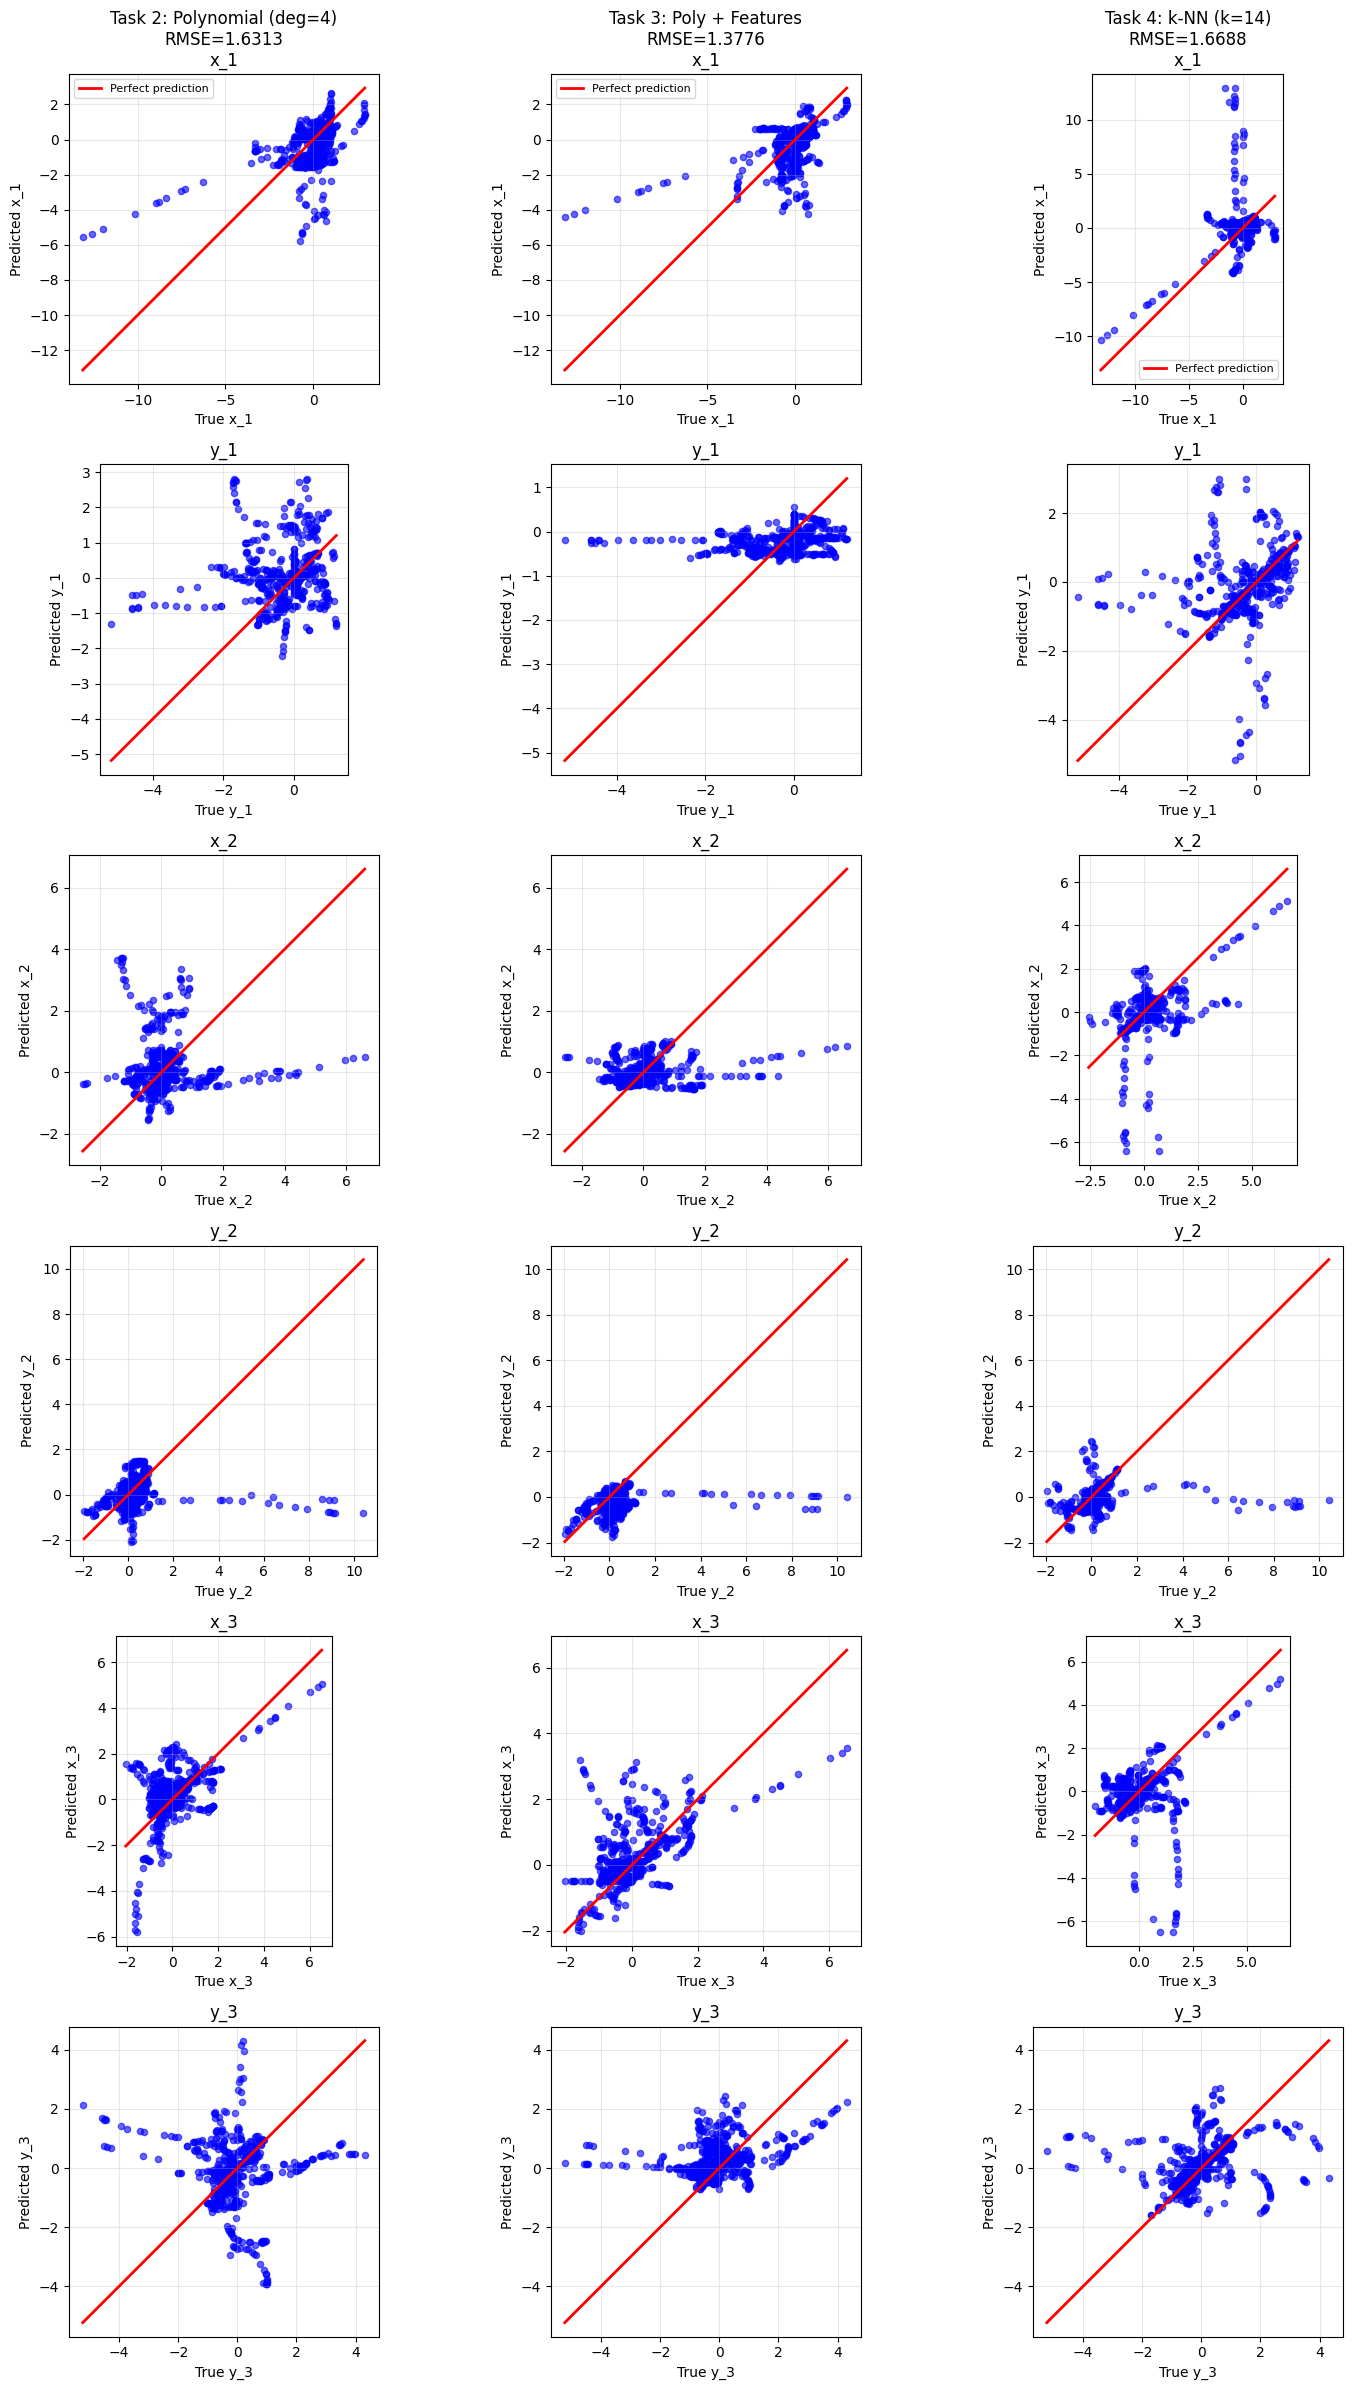


Model Comparison Summary:
Task 2: Polynomial (deg=4)     | RMSE: 1.6313 | MAE: 1.0559
Task 3: Poly + Features        | RMSE: 1.3776 | MAE: 0.8093
Task 4: k-NN (k=14)            | RMSE: 1.6688 | MAE: 0.8335


In [22]:
# Compare all three models with side-by-side y-yhat plots
models_comparison = [
    ('Task 2: Polynomial (deg=4)', y2_pred),
    ('Task 3: Poly + Features', y3_pred),
    ('Task 4: k-NN (k=14)', y4_pred)
]

labels = ['x_1', 'y_1', 'x_2', 'y_2', 'x_3', 'y_3']
MAX = 500

# Sample points if dataset is too large
if len(y_val) > MAX:
    idx = np.random.choice(len(y_val), MAX, replace=False)
else:
    idx = np.arange(len(y_val))

# Create a figure with 3 columns (models) x 6 rows (coordinates)
fig, axes = plt.subplots(6, 3, figsize=(15, 24))

for model_idx, (model_name, y_pred) in enumerate(models_comparison):
    # Calculate RMSE for this model
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    
    for coord_idx in range(6):
        ax = axes[coord_idx, model_idx]
        
        # min/max for diagonal line
        x0 = np.min(y_val[idx, coord_idx])
        x1 = np.max(y_val[idx, coord_idx])
        
        # Scatter plot: predicted vs actual
        ax.scatter(y_val[idx, coord_idx], y_pred[idx, coord_idx], 
                   alpha=0.6, s=20, color='blue')
        
        # Perfect prediction line (diagonal)
        ax.plot([x0, x1], [x0, x1], color='red', linewidth=2, 
                label='Perfect prediction')
        
        ax.set_xlabel(f'True {labels[coord_idx]}')
        ax.set_ylabel(f'Predicted {labels[coord_idx]}')
        
        # Add model name to top row titles
        if coord_idx == 0:
            ax.set_title(f'{model_name}\nRMSE={rmse:.4f}\n{labels[coord_idx]}')
        else:
            ax.set_title(labels[coord_idx])
        
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal', adjustable='box')
        
        if coord_idx == 0:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('results/models_comparison_yhat.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nModel Comparison Summary:")
print("=" * 60)
for model_name, y_pred in models_comparison:
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    print(f"{model_name:30s} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")
print("=" * 60)

Create submission

In [24]:
# model = make_pipeline(
#             StandardScaler(),
#             KNeighborsRegressor(n_neighbors=14)
#         )
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)
# rmse = np.sqrt(mean_squared_error(y_val, y_pred))

# print(rmse)
# export_predictions_to_csv(y_pred, RESULTS_DIR / "knn_submission.csv")